<a href="https://colab.research.google.com/github/rohith154-vsr/ML-2-LAB/blob/main/LP_4_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CAR_EVALUATION.csv not found.
Dataset downloaded successfully!

Dataset shape: (1728, 7)

First 15 rows:
   buying  maint doors persons lug_boot safety Target
0   vhigh  vhigh     2       2    small    low  unacc
1   vhigh  vhigh     2       2    small    med  unacc
2   vhigh  vhigh     2       2    small   high  unacc
3   vhigh  vhigh     2       2      med    low  unacc
4   vhigh  vhigh     2       2      med    med  unacc
5   vhigh  vhigh     2       2      med   high  unacc
6   vhigh  vhigh     2       2      big    low  unacc
7   vhigh  vhigh     2       2      big    med  unacc
8   vhigh  vhigh     2       2      big   high  unacc
9   vhigh  vhigh     2       4    small    low  unacc
10  vhigh  vhigh     2       4    small    med  unacc
11  vhigh  vhigh     2       4    small   high  unacc
12  vhigh  vhigh     2       4      med    low  unacc
13  vhigh  vhigh     2       4      med    med  unacc
14  vhigh  vhigh     2       4      med   high  unacc

Columns:
['buying', 'maint', '

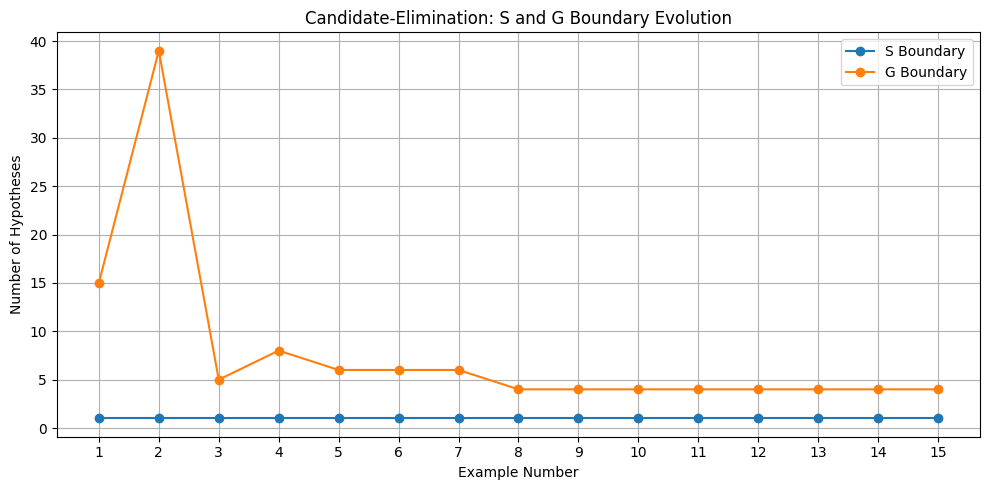


FINAL RESULT AFTER FIRST 15 EXAMPLES

Final S Boundary:
('med', 'med', '?', '?', '?', 'high')

Final G Boundary:
('med', '?', '?', '?', '?', 'high')
('?', 'med', '?', '?', '?', '?')
('?', 'med', '?', '?', '?', 'high')
('med', '?', '?', '?', '?', '?')

Number of S hypotheses: 1
Number of G hypotheses: 4


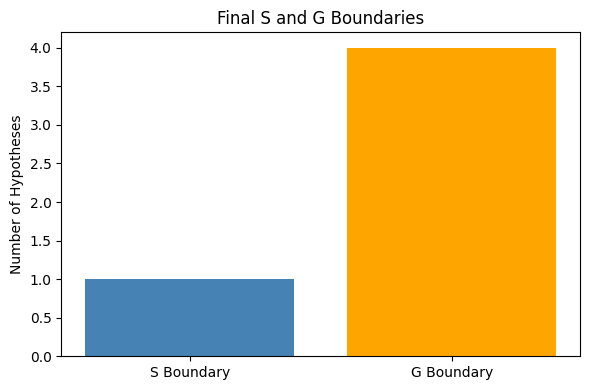


FINAL SUMMARY
Dataset size: (1728, 8)
Total selected examples: 15
Positive examples: 8
Negative examples: 7
Final S hypotheses: 1
Final G hypotheses: 4

PROGRAM COMPLETED


In [1]:
# ============================================================
# CANDIDATE ELIMINATION ALGORITHM - CAR EVALUATION DATASET
# GOOGLE COLAB VERSION
#
# This program:
# 1. Checks whether CAR_EVALUATION.csv exists
# 2. If not, downloads the dataset from UCI automatically
# 3. Creates Positive/Negative classes
# 4. Selects 15 mixed examples
# 5. Applies Candidate-Elimination
# 6. Displays S and G boundaries
# 7. Plots boundary evolution
# 8. Displays final result
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 2. LOAD DATASET
# ============================================================

csv_file = "CAR_EVALUATION.csv"

if os.path.exists(csv_file):

    print("CAR_EVALUATION.csv found.")
    print("Loading dataset from CSV file...")

    df = pd.read_csv(csv_file)

else:

    print("CAR_EVALUATION.csv not found.")
    print("Downloading Car Evaluation dataset automatically...")

    # Download the official UCI Car Evaluation dataset
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

    column_names = [
        "buying",
        "maint",
        "doors",
        "persons",
        "lug_boot",
        "safety",
        "Target"
    ]

    df = pd.read_csv(
        url,
        names=column_names
    )

    print("Dataset downloaded successfully!")


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\nDataset shape:", df.shape)

print("\nFirst 15 rows:")
print(df.head(15))

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget classes:")
print(df["Target"].value_counts())


# ============================================================
# 4. CONVERT ORIGINAL CLASSES INTO BINARY CLASSES
#
# good and vgood = Positive
# unacc and acc  = Negative
# ============================================================

df["Class"] = df["Target"].apply(
    lambda x:
    "Positive"
    if x in ["good", "vgood"]
    else "Negative"
)


# ============================================================
# 5. DEFINE FEATURES
# ============================================================

features = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety"
]


print("\nTarget and binary class:")
print(
    df[
        ["Target", "Class"]
    ].head(15)
)

print("\nClass distribution:")
print(
    df["Class"].value_counts()
)


# ============================================================
# 6. SELECT 15 MIXED EXAMPLES
#
# 8 Positive + 7 Negative
# ============================================================

positive = df[
    df["Class"] == "Positive"
]

negative = df[
    df["Class"] == "Negative"
]


selected_rows = []


# Select 8 positive examples
for i in range(8):

    selected_rows.append(
        positive.iloc[i]
    )


# Select 7 negative examples
for i in range(7):

    selected_rows.append(
        negative.iloc[i]
    )


sample_df = pd.DataFrame(
    selected_rows
)


# Shuffle examples
sample_df = sample_df.sample(
    frac=1,
    random_state=42
).reset_index(
    drop=True
)


print("\n============================================")
print("SELECTED 15 MIXED EXAMPLES")
print("============================================")

print(
    sample_df[
        ["Target", "Class"] + features
    ]
)


# ============================================================
# 7. FUNCTION: CHECK WHETHER HYPOTHESIS COVERS EXAMPLE
# ============================================================

def covers(hypothesis, example):

    for h, x in zip(
        hypothesis,
        example
    ):

        # Empty hypothesis covers nothing
        if h == "Ø":
            return False

        # ? matches any value
        if h == "?":
            continue

        # Specific value must match
        if h != x:
            return False

    return True


# ============================================================
# 8. FUNCTION:
# CHECK WHETHER H1 IS MORE GENERAL THAN OR EQUAL TO H2
# ============================================================

def more_general_or_equal(
    h1,
    h2
):

    for a, b in zip(
        h1,
        h2
    ):

        # Anything is more general than Ø
        if b == "Ø":
            continue

        # ? is more general than any value
        if a == "?":
            continue

        # Specific values must be equal
        if a != b:
            return False

    return True


# ============================================================
# 9. GENERATE MINIMAL SPECIALIZATIONS
# ============================================================

def minimal_specializations(
    hypothesis,
    example,
    domains
):

    specializations = set()

    for i in range(
        len(hypothesis)
    ):

        if hypothesis[i] == "?":

            for value in domains[
                features[i]
            ]:

                if value != example[i]:

                    new_h = list(
                        hypothesis
                    )

                    new_h[i] = value

                    specializations.add(
                        tuple(new_h)
                    )

    return specializations


# ============================================================
# 10. GET POSSIBLE VALUES FOR EACH FEATURE
# ============================================================

domains = {
    feature:
    df[feature].unique().tolist()
    for feature in features
}


print("\n============================================")
print("FEATURE DOMAINS")
print("============================================")

for feature in features:

    print(
        f"{feature:12s}: {domains[feature]}"
    )


# ============================================================
# 11. INITIALIZE S AND G
# ============================================================

# Most specific hypothesis
S = {
    tuple(
        ["Ø"] * len(features)
    )
}


# Most general hypothesis
G = {
    tuple(
        ["?"] * len(features)
    )
}


# Store history
S_history = []
G_history = []


# ============================================================
# 12. CANDIDATE-ELIMINATION ALGORITHM
# ============================================================

for _, row in sample_df.iterrows():

    example = tuple(
        row[feature]
        for feature in features
    )


    # ========================================================
    # POSITIVE EXAMPLE
    # ========================================================

    if row["Class"] == "Positive":

        # Remove G hypotheses that do not cover
        # the positive example

        G = {
            g
            for g in G
            if covers(
                g,
                example
            )
        }


        new_S = set()


        for s in S:

            # If S already covers example
            if covers(
                s,
                example
            ):

                new_S.add(s)


            else:

                h = list(s)


                for i in range(
                    len(features)
                ):

                    # Replace Ø with example value
                    if s[i] == "Ø":

                        h[i] = example[i]


                    # Generalize different values
                    elif s[i] != example[i]:

                        h[i] = "?"


                h = tuple(h)


                # Keep only hypotheses
                # that are below some G hypothesis

                if any(
                    more_general_or_equal(
                        g,
                        h
                    )
                    for g in G
                ):

                    new_S.add(h)


        S = new_S


    # ========================================================
    # NEGATIVE EXAMPLE
    # ========================================================

    else:

        new_G = set()


        for g in G:

            # If G does not cover negative example,
            # keep it

            if not covers(
                g,
                example
            ):

                new_G.add(g)


            else:

                # Specialize G
                for i in range(
                    len(features)
                ):

                    if g[i] == "?":

                        for value in domains[
                            features[i]
                        ]:

                            if value != example[i]:

                                h = list(g)

                                h[i] = value

                                h = tuple(h)


                                # Keep specialization only if
                                # it is more general than
                                # at least one S hypothesis

                                if any(
                                    more_general_or_equal(
                                        h,
                                        s
                                    )
                                    for s in S
                                ):

                                    new_G.add(h)


        G = new_G


    # ========================================================
    # SAVE BOUNDARIES
    # ========================================================

    S_history.append(
        S.copy()
    )

    G_history.append(
        G.copy()
    )


# ============================================================
# 13. DISPLAY S AND G AFTER EVERY EXAMPLE
# ============================================================

for i in range(
    len(sample_df)
):

    print(
        "\n" + "=" * 60
    )

    print(
        "AFTER EXAMPLE",
        i + 1
    )

    print(
        "=" * 60
    )

    print(
        "Target:",
        sample_df.iloc[i]["Target"]
    )

    print(
        "Class :",
        sample_df.iloc[i]["Class"]
    )


    print("\nS Boundary:")

    for s in S_history[i]:

        print(s)


    print("\nG Boundary:")

    for g in G_history[i]:

        print(g)


# ============================================================
# 14. COUNT S AND G HYPOTHESES
# ============================================================

S_count = [
    len(s)
    for s in S_history
]

G_count = [
    len(g)
    for g in G_history
]


# ============================================================
# 15. PLOT S AND G BOUNDARY EVOLUTION
# ============================================================

examples = range(
    1,
    len(sample_df) + 1
)


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    examples,
    S_count,
    marker="o",
    label="S Boundary"
)


plt.plot(
    examples,
    G_count,
    marker="o",
    label="G Boundary"
)


plt.xlabel(
    "Example Number"
)

plt.ylabel(
    "Number of Hypotheses"
)

plt.title(
    "Candidate-Elimination: S and G Boundary Evolution"
)


plt.xticks(
    range(
        1,
        len(sample_df) + 1
    )
)


plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 16. FINAL RESULT
# ============================================================

final_S = S_history[-1]

final_G = G_history[-1]


print(
    "\n" + "=" * 60
)

print(
    "FINAL RESULT AFTER FIRST 15 EXAMPLES"
)

print(
    "=" * 60
)


print("\nFinal S Boundary:")

for s in final_S:

    print(s)


print("\nFinal G Boundary:")

for g in final_G:

    print(g)


print(
    "\nNumber of S hypotheses:",
    len(final_S)
)


print(
    "Number of G hypotheses:",
    len(final_G)
)


# ============================================================
# 17. FINAL S AND G BOUNDARY PLOT
# ============================================================

plt.figure(
    figsize=(6, 4)
)


plt.bar(
    ["S Boundary", "G Boundary"],
    [
        len(final_S),
        len(final_G)
    ],
    color=[
        "steelblue",
        "orange"
    ]
)


plt.ylabel(
    "Number of Hypotheses"
)

plt.title(
    "Final S and G Boundaries"
)


plt.tight_layout()

plt.show()


# ============================================================
# 18. DISPLAY SELECTED EXAMPLES WITH FINAL RESULT
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "FINAL SUMMARY"
)

print(
    "=" * 60
)

print(
    "Dataset size:",
    df.shape
)

print(
    "Total selected examples:",
    len(sample_df)
)

print(
    "Positive examples:",
    len(
        sample_df[
            sample_df["Class"] == "Positive"
        ]
    )
)

print(
    "Negative examples:",
    len(
        sample_df[
            sample_df["Class"] == "Negative"
        ]
    )
)

print(
    "Final S hypotheses:",
    len(final_S)
)

print(
    "Final G hypotheses:",
    len(final_G)
)


print(
    "\n============================================"
)

print(
    "PROGRAM COMPLETED"
)

print(
    "============================================"
)